In [2]:
import pandas as pd
import ast
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply({lambda x: ast.literal_eval(x) if pd.notna(x) else(x)})

In [3]:
df_DA_india = df[(df['job_title_short'] == 'Data Analyst') & (df['job_location'] == 'India')].copy()

df_DA_india = df_DA_india.dropna(subset=['salary_year_avg'])

In [4]:
df_DA_india = df_DA_india.explode('job_skills')

df_DA_india[['salary_year_avg','job_skills']]

df_DA_india_group=df_DA_india.groupby('job_skills')['salary_year_avg'].agg(['count','median'])

df_DA_top_pay = df_DA_india_group.sort_values(by='median', ascending=False).head(10)

df_DA_skill = df_DA_india_group.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False).head(10)

df_DA_skill

,count,median
job_skills,,
flow,2,96603.75
word,3,89118.00
excel,8,82092.75
sql,9,79200.00
tableau,3,79200.00
windows,1,79200.00
python,6,75400.00
oracle,1,75067.50
r,3,71600.00


C:\Users\rutvi\AppData\Local\Temp\ipykernel_3480\1578785376.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_DA_top_pay[::-1], x='median', y=df_DA_top_pay.index, ax=ax[0], palette='dark:b_r')
C:\Users\rutvi\AppData\Local\Temp\ipykernel_3480\1578785376.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_DA_skill[::-1], x='median', y=df_DA_skill.index, ax=ax[1], palette='light:b')


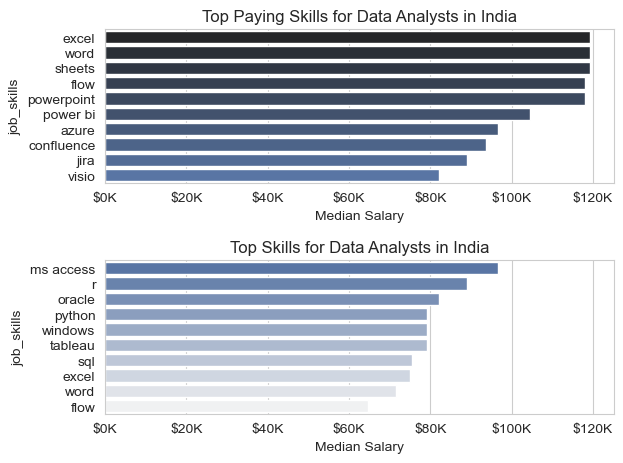

In [8]:
fig, ax = plt.subplots(2,1)
sns.set_theme(style='ticks')

sns.barplot(data=df_DA_top_pay[::-1], x='median', y=df_DA_top_pay.index, ax=ax[0], palette='dark:b_r')
#df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].set_title('Top Paying Skills for Data Analysts in India')
ax[0].set_xlabel('Median Salary')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${int(x/1000)}K'))
ax[0].invert_yaxis()  # Invert y-axis to have the highest paying skill on top
fig.tight_layout()


sns.barplot(data=df_DA_skill[::-1], x='median', y=df_DA_skill.index, ax=ax[1], palette='light:b')  
#df_DA_skill[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('Top Skills for Data Analysts in India')
ax[1].set_xlabel('Median Salary')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].invert_yaxis()  # Invert y-axis to have the highest paying skill on top
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'${int(x/1000)}K'))

fig.tight_layout()
plt.show()

In [9]:
df_india = df[(df['job_title_short'] == 'Data Analyst') & (df['job_location'] == 'India')].copy()
df_india['salary_year_avg']

38       NaN
194      NaN
691      NaN
963      NaN
1336     NaN
          ..
782917   NaN
784121   NaN
784307   NaN
785181   NaN
785715   NaN
Name: salary_year_avg, Length: 2056, dtype: float64

(0.0, 130000.0)

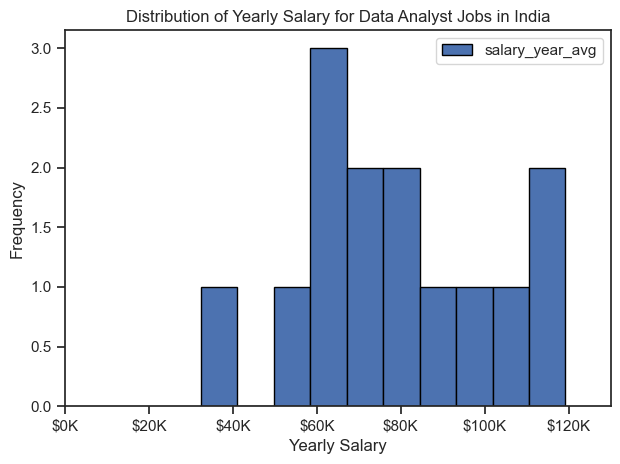

In [10]:
df_india.plot(kind='hist', y='salary_year_avg', bins=10, edgecolor='black')

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

plt.title('Distribution of Yearly Salary for Data Analyst Jobs in India')
plt.xlabel('Yearly Salary')
plt.ylabel('Frequency')
plt.tight_layout()
plt.xlim(0, 130000)

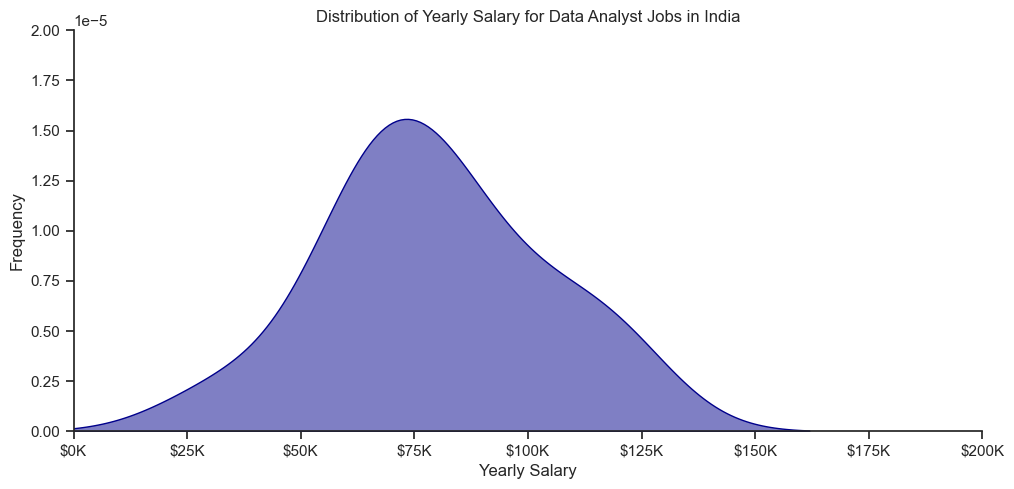

In [37]:
sns.displot(df_india['salary_year_avg'], kind = 'kde', fill=True, height=5, aspect=2, color='darkblue', alpha=0.5)
sns.set_theme(style='ticks')

plt.title('Distribution of Yearly Salary for Data Analyst Jobs in India')
plt.xlabel('Yearly Salary')
plt.ylabel('Frequency')
plt.ylim(0, 0.00002)
plt.xlim(0, 200000)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.show()

C:\Users\rutvi\AppData\Local\Temp\ipykernel_3480\1733070621.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


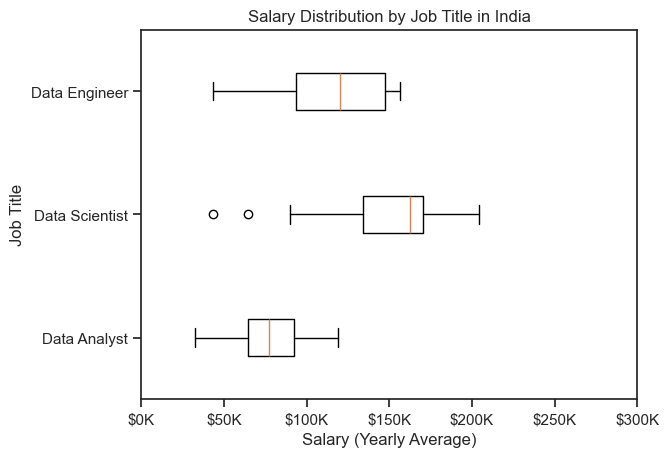

In [38]:
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

df_india = df[(df['job_title_short'].isin(job_titles)) & (df['job_location'] == 'India')].copy()
df_india=df_india.dropna(subset=['salary_year_avg'])

job_list = [df_india[df_india['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, labels=job_titles, vert=False)
plt.title('Salary Distribution by Job Title in India')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0, 300000)
plt.xlabel('Salary (Yearly Average)')
plt.ylabel('Job Title')
plt.show()

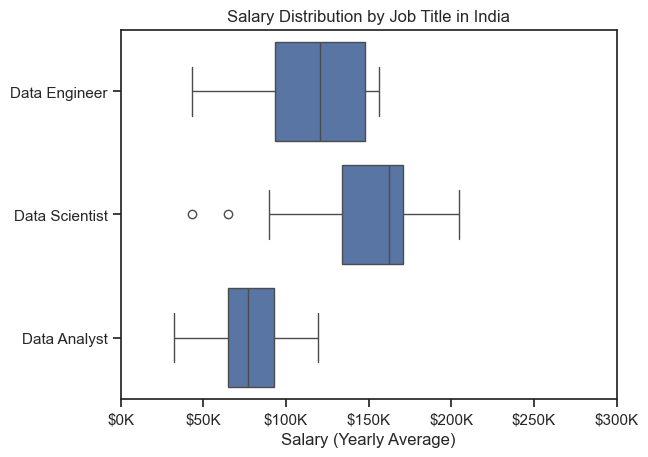

In [40]:
sns.boxplot(data=df_india, x='salary_year_avg', y='job_title_short')

plt.title('Salary Distribution by Job Title in India')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0, 300000)
plt.xlabel('Salary (Yearly Average)')
plt.ylabel('')
plt.show()